## Adding observational effects on synthetic imaging data cube
To bridge the gap between theoretical models and observational data, it is essential to account for the limitations of astronomical instruments. The ``GalSynMockObservation_imaging`` class in the ``observe`` module transforms idealized synthetic images into realistic mock observations. The process include spatial resapling (to a user-defined pixel scale, matching to the instrument characterictics), PSF convolution, noise simulation and injection. Please refer Abdurro'uf et al. (2026) for detailed descriptions about the algorithm used. 

Below is an example script for adding the observational effects into a synthetic data cube. First, we define the telescope and sky conditions for each filter. This includes providing the PSF images, instrumental zero-points, and the desired noise characteristics.

In [7]:
from galsyn import GalSynMockObservation_imaging
from galsyn.utils import make_filter_transmission_text_pixedfit

# select a set of filters to be processed
filters = ['hst_acs_f435w', 'hst_acs_f606w', 'hst_acs_f814w', 'hst_wfc3_ir_f125w',
            'hst_wfc3_ir_f140w', 'hst_wfc3_ir_f160w', 'jwst_nircam_f090w', 'jwst_nircam_f115w',
            'jwst_nircam_f150w', 'jwst_nircam_f200w', 'jwst_nircam_f277w', 'jwst_nircam_f356w',
            'jwst_nircam_f410m', 'jwst_nircam_f444w']

filter_transmission_path1 = make_filter_transmission_text_pixedfit(filters, output_dir="filters")

# Pixel size of your provided PSF images
psf_pixel_scales = {'hst_acs_f435w': 0.04, 'hst_acs_f606w': 0.04,
            'hst_acs_f814w': 0.04, 'hst_wfc3_ir_f125w': 0.04,
            'hst_wfc3_ir_f140w': 0.04, 'hst_wfc3_ir_f160w': 0.04,
            'jwst_nircam_f090w': 0.02, 'jwst_nircam_f115w': 0.02,
            'jwst_nircam_f150w': 0.02, 'jwst_nircam_f200w': 0.02,
            'jwst_nircam_f277w': 0.04, 'jwst_nircam_f356w': 0.04,
            'jwst_nircam_f410m': 0.04, 'jwst_nircam_f444w': 0.04}

# Desired limiting magnitudes to be achieved
limiting_magnitude = {'hst_acs_f435w': 29.3, 'hst_acs_f606w': 29.1,
                'hst_acs_f814w': 29.1, 'hst_wfc3_ir_f125w': 28.5,
                'hst_wfc3_ir_f140w': 28.2, 'hst_wfc3_ir_f160w': 29.1,
                'jwst_nircam_f090w': 29.7, 'jwst_nircam_f115w': 30.2,
                'jwst_nircam_f150w': 29.9, 'jwst_nircam_f200w': 30.1, 
                'jwst_nircam_f277w': 30.9, 'jwst_nircam_f356w': 30.8,
                'jwst_nircam_f410m': 30.1, 'jwst_nircam_f444w': 30.2}

# Exposure time used in the observations in seconds.
exposure_time = {'hst_acs_f435w': 68473, 'hst_acs_f606w': 11525,
                'hst_acs_f814w': 61992, 'hst_wfc3_ir_f125w': 18281,
                'hst_wfc3_ir_f140w': 6903, 'hst_wfc3_ir_f160w': 19382,
                'jwst_nircam_f090w': 11338, 'jwst_nircam_f115w': 22676,
                'jwst_nircam_f150w': 11338, 'jwst_nircam_f200w': 11338, 
                'jwst_nircam_f277w': 11330, 'jwst_nircam_f356w': 11328, 
                'jwst_nircam_f410m': 8503, 'jwst_nircam_f444w': 11319}

# Target depth and instrument parameters
psf_paths = {ff: f"PSF_{ff}.fits" for ff in filters}
mag_zp = {ff: 28.1 for ff in filters}
snr_limit = {ff: 5.0 for ff in filters}
aperture_radius_arcsec = {ff: 0.1 for ff in filters}
desired_pixel_scales = {ff: 0.03 for ff in filters} # Final resampled resolution

fits_file_path = 'galsyn_39_107965_photo.fits'

# Initialize the mock observation object
simg = GalSynMockObservation_imaging(fits_file_path, filters, psf_paths, psf_pixel_scales, mag_zp,
                                    limiting_magnitude, snr_limit, aperture_radius_arcsec,
                                    exposure_time, filter_transmission_path1, desired_pixel_scales)

# Start the pipeline: Resampling -> PSF Convolution -> Noise Injection
simg.process_images(apply_noise_to_image=True, dust_attenuation=True)

# Save the resulting science and RMS extensions to a new FITS file
output_fits_path = 'obsimg_galsyn_39_107965_photo_30mas.fits'
simg.save_results_to_fits(output_fits_path=output_fits_path)


Directory 'filters' already exists.

Starting full image processing pipeline...
Processing Filter: hst_acs_f435w
Processing Filter: hst_acs_f606w
Processing Filter: hst_acs_f814w
Processing Filter: hst_wfc3_ir_f125w
Processing Filter: hst_wfc3_ir_f140w
Processing Filter: hst_wfc3_ir_f160w
Processing Filter: jwst_nircam_f090w
Processing Filter: jwst_nircam_f115w
Processing Filter: jwst_nircam_f150w
Processing Filter: jwst_nircam_f200w
Processing Filter: jwst_nircam_f277w
Processing Filter: jwst_nircam_f356w
Processing Filter: jwst_nircam_f410m
Processing Filter: jwst_nircam_f444w
Results saved to obsimg_galsyn_39_107965_photo_30mas.fits


### Check resulting data cube


In [8]:
from astropy.io import fits 

cube = fits.open('obsimg_galsyn_39_107965_photo_30mas.fits')
cube.info()

Filename: obsimg_galsyn_39_107965_photo_30mas.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1  SCI_DUST_HST_ACS_F435W    1 ImageHDU         9   (345, 345)   float64   
  2  SCI_DUST_HST_ACS_F606W    1 ImageHDU         9   (345, 345)   float64   
  3  SCI_DUST_HST_ACS_F814W    1 ImageHDU         9   (345, 345)   float64   
  4  SCI_DUST_HST_WFC3_IR_F125W    1 ImageHDU         9   (345, 345)   float64   
  5  SCI_DUST_HST_WFC3_IR_F140W    1 ImageHDU         9   (345, 345)   float64   
  6  SCI_DUST_HST_WFC3_IR_F160W    1 ImageHDU         9   (345, 345)   float64   
  7  SCI_DUST_JWST_NIRCAM_F090W    1 ImageHDU         9   (345, 345)   float64   
  8  SCI_DUST_JWST_NIRCAM_F115W    1 ImageHDU         9   (345, 345)   float64   
  9  SCI_DUST_JWST_NIRCAM_F150W    1 ImageHDU         9   (345, 345)   float64   
 10  SCI_DUST_JWST_NIRCAM_F200W    1 ImageHDU         9   (345, 345)   float64   
 11  SCI_DUST_JWST_NIRCAM_F2

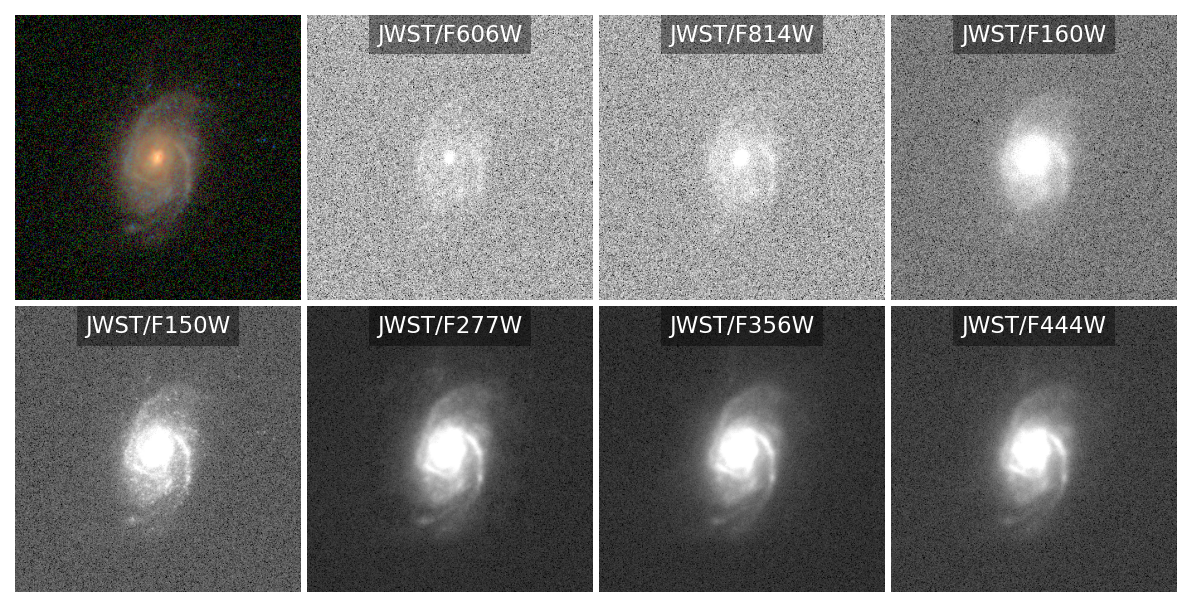

In [24]:
%matplotlib inline

import matplotlib.pyplot as plt
from astropy.visualization import simple_norm, make_lupton_rgb

# Filter configuration
fils = ['hst_acs_f606w', 'hst_acs_f814w', 'hst_wfc3_ir_f160w', 'jwst_nircam_f150w', 
        'jwst_nircam_f277w', 'jwst_nircam_f356w', 'jwst_nircam_f444w']
filnames = ['JWST/F606W', 'JWST/F814W', 'JWST/F160W', 'JWST/F150W', 
            'JWST/F277W', 'JWST/F356W', 'JWST/F444W']
nbands = len(fils)

# RGB components (using JWST NIRCam filters)
rgb_fils = ['jwst_nircam_f115w', 'jwst_nircam_f150w', 'jwst_nircam_f200w']

nrows, ncols = 2, 4
fig = plt.figure(figsize=(ncols*2.5, nrows*2.5), dpi=150)

# RGB Composite
ax_rgb = fig.add_subplot(nrows, ncols, 1)
factor = 2e+3

# Access data using the standard 'DUST[FILTER]' extension name 
r = cube[f'SCI_DUST_{rgb_fils[2]}'].data * factor
g = cube[f'SCI_DUST_{rgb_fils[1]}'].data * factor
b = cube[f'SCI_DUST_{rgb_fils[0]}'].data * factor

rgb = make_lupton_rgb(r, g, b, stretch=50, Q=10)
ax_rgb.imshow(rgb, origin='lower')
ax_rgb.axis('off') # Cleanly removes all ticks and labels

# Individual Grayscale Bands
for ii in range(nbands):
    ax = fig.add_subplot(nrows, ncols, ii+2)
    
    # Access dust-attenuated imaging data 
    data = cube[f'SCI_DUST_{fils[ii]}'].data
    
    # Apply square-root normalization to improve dynamic range visibility
    norm = simple_norm(data, 'sqrt', percent=97.5)
    ax.imshow(data, norm=norm, origin='lower', cmap='gray')
    ax.axis('off')

    # Add filter labels with a small background box for readability
    ax.text(0.5, 0.93, filnames[ii], color='white', fontsize=11,
            ha='center', va='center', transform=ax.transAxes,
            bbox=dict(facecolor='black', alpha=0.4, lw=0))

plt.subplots_adjust(hspace=0.02, wspace=0.02)
plt.show()